# Packages

In [93]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

import warnings

import joblib

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Analysis and organization

In [76]:
# Carregar o arquivo
df = pd.read_csv('data/dados_quantum_walk_T_100_50.csv')

# Visualizar as primeiras linhas
df.head()

,delta_theta,IPR,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.000000,16.049482,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.010686,16.109290,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.021371,17.274234,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.032057,17.394967,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.042743,21.982325,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


In [77]:
# Seleciona as colunas e mantém como um DataFrame, mas colocando values ele cria uma nova matriz
df_probs = df.filter(like='prob_')
df_probs.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.000140,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,0.0,0.000146,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,0.0,0.000119,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,0.0,0.000170,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,0.0,0.000141,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


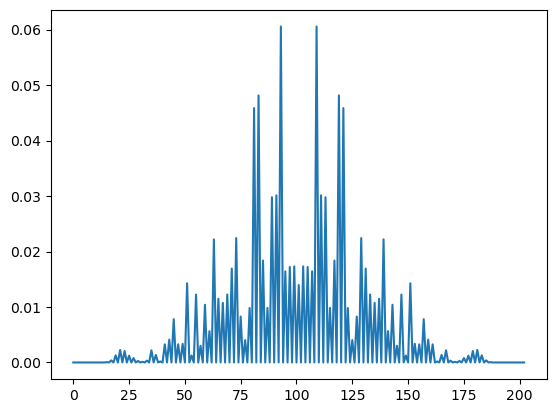

In [78]:
plt.plot(df_probs.iloc[25].values)
plt.show()

List of IPR

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


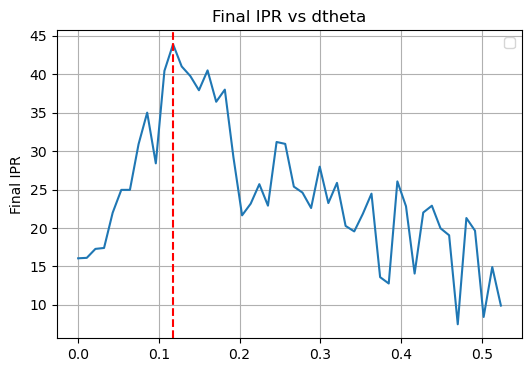

In [79]:
IPR_list = df['IPR']

plt.figure(figsize=(6,4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500])
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

In [80]:
df.iloc[np.argmax(IPR_list)]
critical_exp = df['delta_theta'].iloc[np.argmax(IPR_list)]
critical_exp

0.1175425822771691

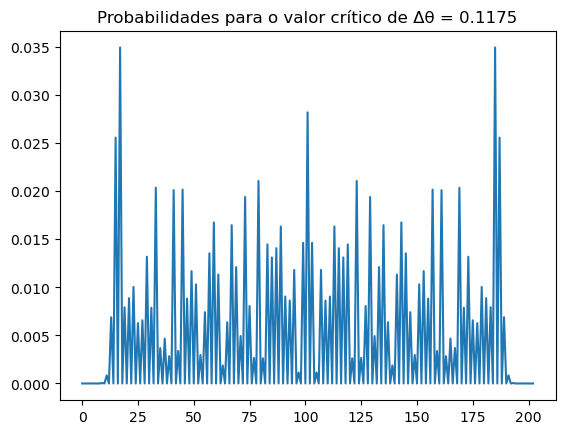

In [81]:
plt.plot(df_probs.iloc[np.argmax(IPR_list)].values)
plt.title(f'Probabilidades para o valor crítico de Δθ = {critical_exp:.4f}')
plt.show()

Data separation for training: Label 0 is assigned to delocalized states (ranging from $0$ to $50$), and Label 1 to localized states (ranging from $200$ to $250$).

In [82]:
# Assigning labels to the training data

n_total = len(df)
ponto_de_corte = np.argmax(df['IPR'].values)  # Onde os 0s terminam e os 1s começam

# Cria a coluna: metade 0, metade 1
coluna_rotulo = np.concatenate([
    np.zeros(ponto_de_corte), 
    np.ones(n_total - ponto_de_corte)
])

# Adiciona a coluna ao DataFrame e garanto que seja inteira
df_probs['label'] = coluna_rotulo.astype(int)

/tmp/ipykernel_19446/2789398605.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_probs['label'] = coluna_rotulo.astype(int)


Pego os 50 primeiros deslocalizados e depois mais 50 localizados

In [83]:
df_training = df_probs.iloc[np.r_[0:8, 42:50]]

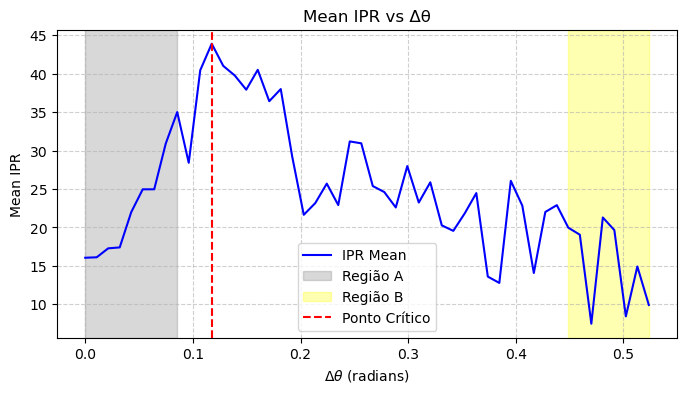

In [84]:
plt.figure(figsize=(8, 4))
plt.plot(df['delta_theta'].values,df['IPR'].values, label='IPR Mean', color='blue', zorder=2)

# Colorindo o primeiro intervalo [0:300]
plt.axvspan(df['delta_theta'].values[:][0], df['delta_theta'].values[:][8], 
            color='gray', alpha=0.3, label='Região A')

# Colorindo o segundo intervalo [700:1000]
# Nota: se o índice for 1000, use 999 para não estourar o limite do array
plt.axvspan(df['delta_theta'].values[:][42], df['delta_theta'].values[:][49], 
            color='yellow', alpha=0.3, label='Região B')

plt.title('Mean IPR vs Δθ')
plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Mean IPR')
plt.axvline(x=critical_exp, color='red', linestyle='--', label='Ponto Crítico')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

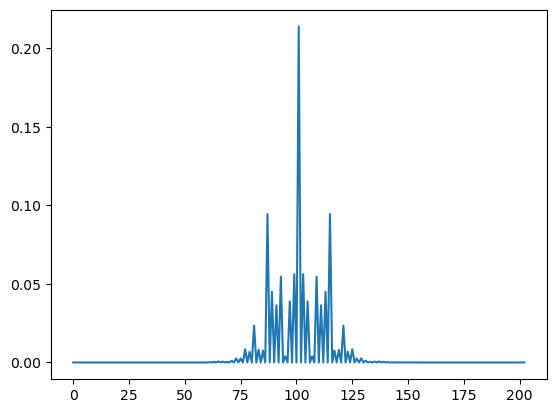

In [85]:
plt.plot(df_probs.iloc[49].values[:-1])
plt.show()

In [86]:
len(df_probs.iloc[49].values)

204

Spliting 80% for training data and 20% for testing model's accuracy. Choice made radomly.

In [87]:
# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train = df_training.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test = df_training.drop(df_train.index)

In [88]:
df_train.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202,label
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,4.000856e-06,0.0,1.397188e-04,...,0.0,4.000856e-06,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0,0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,4.209793e-06,0.0,1.458290e-04,...,0.0,4.209793e-06,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0,0
5,0.0,5.365476e-13,0.0,5.196309e-10,0.0,1.032697e-07,0.0,7.293757e-06,0.0,2.236475e-04,...,0.0,7.293757e-06,0.0,1.032697e-07,0.0,5.196309e-10,0.0,5.365476e-13,0.0,0
48,0.0,4.257465e-32,0.0,2.594491e-28,0.0,3.219640e-25,0.0,1.413168e-22,0.0,2.689253e-20,...,0.0,1.413168e-22,0.0,3.219640e-25,0.0,2.594491e-28,0.0,4.257465e-32,0.0,1
47,0.0,3.842752e-30,0.0,1.734951e-26,0.0,1.615047e-23,0.0,5.402049e-21,0.0,8.005230e-19,...,0.0,5.402049e-21,0.0,1.615047e-23,0.0,1.734951e-26,0.0,3.842752e-30,0.0,1


# Training

## SVM

In [89]:
def sigmoide_automatica(x, y):
    # --- AUTO-CHUTE (O segredo para não falhar) ---
    # Centro (x0): Onde o y está mais próximo de 0.5
    x0_chute = x[np.argmin(np.abs(y - 0.5))]
    
    # Inclinação (k): Estimada pela diferença entre os extremos
    # Se a curva sobe, k é positivo. Se desce, k é negativo.
    k_chute = (y[-1] - y[0]) / (x[-1] - x[0]) * 4 

    # Função modelo: Sigmóide padrão
    def f(x, k, x0):
        return 1 / (1 + np.exp(-k * (x - x0)))

    # Ajuste com os chutes calculados automaticamente
    popt, pcov = curve_fit(f, x, y, p0=[k_chute, x0_chute])
    
    return popt # Retorna [k, x0]

In [90]:
X_train = df_train.drop(columns=['label']).values
y_train = df_train['label'].values

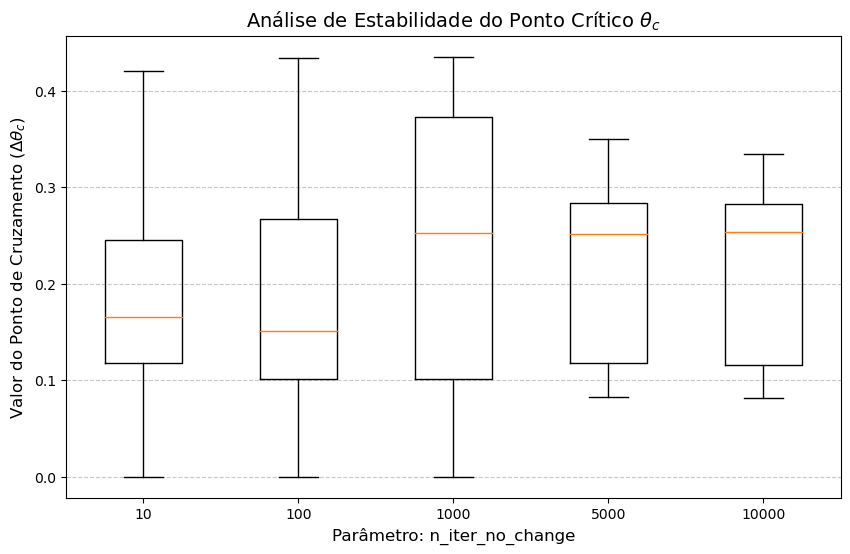

In [95]:
warnings.filterwarnings("ignore")

# Configurações do Teste
n_execucoes = 100  # Quantas vezes rodar cada parâmetro para gerar a estatística
parametros_teste = [10, 100, 1000, 5000,10000]  # Valores de n_iter_no_change para testar
resultados_finais = []

for p in parametros_teste:
    pontos_criticos_p = []
    #print(f"Testando n_iter_no_change = {p}...")
    
    for i in range(n_execucoes):
        # 1. Treinar modelo (Sem seed fixa para capturar a variância real)
        clf = SGDClassifier(
            loss='modified_huber', 
            penalty='l2', 
            alpha=0.00001,
            max_iter=5000, 
            tol=1e-5, 
            learning_rate='optimal',
            early_stopping=True,
            n_iter_no_change=p
            
        )
        clf.fit(X_train, y_train)
        
        # 2. Obter as probabilidades para os dados de transição
        probs = clf.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
        delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
        prob_delocalized = probs[:, 0]

        # 3. Tentativa de Fitting com salvamento de 0 em caso de erro
        try:
            # Tenta o ajuste
            res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
            x0 = res_fit[1]
        except Exception:
            # Se der erro (maxfev, etc), salva 0 para indicar "instabilidade total"
            x0 = 0
        
        pontos_criticos_p.append(x0)
        
    resultados_finais.append(pontos_criticos_p)

# --- Plotagem do Gráfico Acadêmico ---
plt.figure(figsize=(10, 6))
plt.boxplot(resultados_finais, labels=parametros_teste)

plt.title("Análise de Estabilidade do Ponto Crítico " + r"$\theta_c$", fontsize=14)
plt.xlabel("Parâmetro: n_iter_no_change", fontsize=12)
plt.ylabel(r"Valor do Ponto de Cruzamento ($\Delta\theta_c$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando uma linha horizontal se você já tiver o valor teórico
# plt.axhline(y=0.20, color='r', linestyle=':', label='Valor Teórico')

plt.show()

In [96]:
np.savetxt('resultados_finais.txt', resultados_finais)

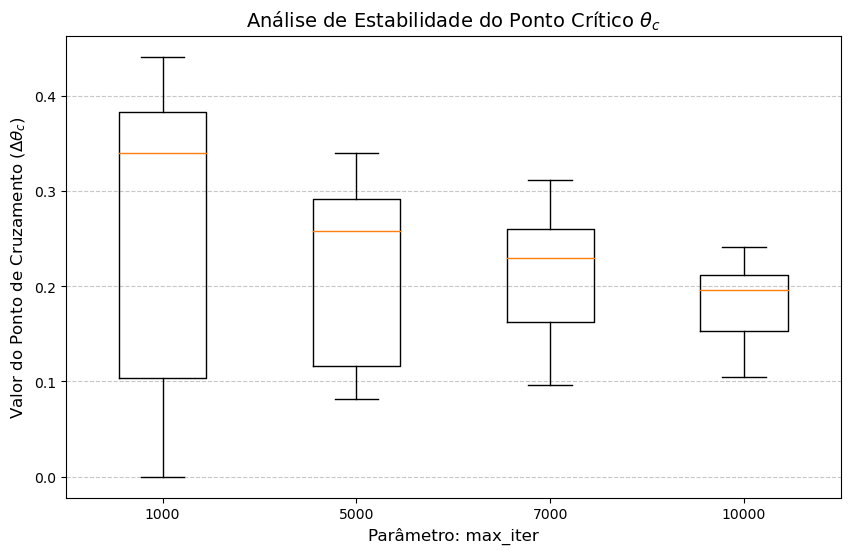

In [97]:
warnings.filterwarnings("ignore")

# Configurações do Teste
n_execucoes = 100  # Quantas vezes rodar cada parâmetro para gerar a estatística
parametros_teste = [1000, 5000, 7000,10000]  # Valores de n_iter_no_change para testar
resultados_finais = []

for p in parametros_teste:
    pontos_criticos_p = []
    #print(f"Testando n_iter_no_change = {p}...")
    
    for i in range(n_execucoes):
        # 1. Treinar modelo (Sem seed fixa para capturar a variância real)
        clf = SGDClassifier(
            loss='modified_huber', 
            penalty='l2', 
            alpha=0.00001,
            max_iter=p, 
            tol=1e-5, 
            learning_rate='optimal',
            early_stopping=True,
            n_iter_no_change=10000
            
        )
        clf.fit(X_train, y_train)
        
        # 2. Obter as probabilidades para os dados de transição
        probs = clf.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
        delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
        prob_delocalized = probs[:, 0]

        # 3. Tentativa de Fitting com salvamento de 0 em caso de erro
        try:
            # Tenta o ajuste
            res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
            x0 = res_fit[1]
        except Exception:
            # Se der erro (maxfev, etc), salva 0 para indicar "instabilidade total"
            x0 = 0
        
        pontos_criticos_p.append(x0)
        
    resultados_finais.append(pontos_criticos_p)

# --- Plotagem do Gráfico Acadêmico ---
plt.figure(figsize=(10, 6))
plt.boxplot(resultados_finais, labels=parametros_teste)

plt.title("Análise de Estabilidade do Ponto Crítico " + r"$\theta_c$", fontsize=14)
plt.xlabel("Parâmetro: max_iter", fontsize=12)
plt.ylabel(r"Valor do Ponto de Cruzamento ($\Delta\theta_c$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando uma linha horizontal se você já tiver o valor teórico
# plt.axhline(y=0.20, color='r', linestyle=':', label='Valor Teórico')

plt.show()

In [98]:
np.savetxt('resultados_finais_max_iter.txt', resultados_finais)

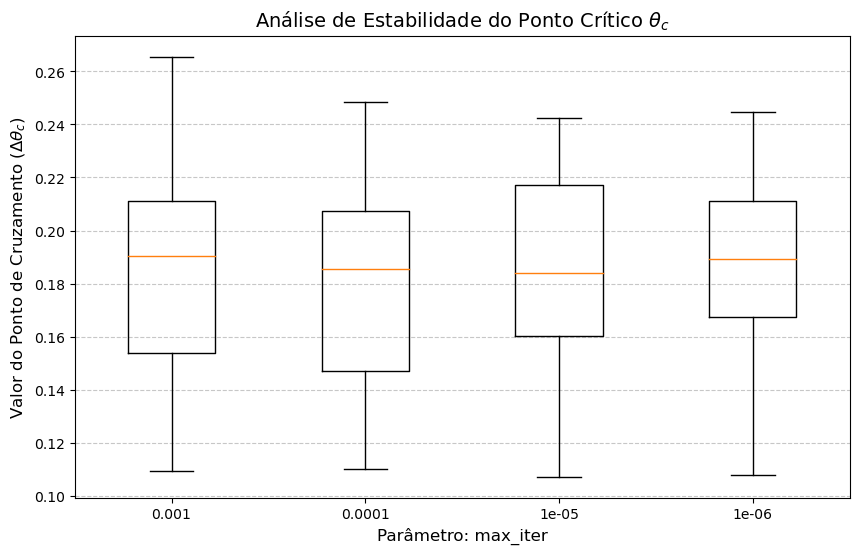

In [99]:
warnings.filterwarnings("ignore")

# Configurações do Teste
n_execucoes = 50  # Quantas vezes rodar cada parâmetro para gerar a estatística
parametros_teste = [1e-3, 1e-4, 1e-5,1e-6]  # Valores de n_iter_no_change para testar
resultados_finais3 = []

for p in parametros_teste:
    pontos_criticos_p = []
    #print(f"Testando n_iter_no_change = {p}...")
    
    for i in range(n_execucoes):
        # 1. Treinar modelo (Sem seed fixa para capturar a variância real)
        clf = SGDClassifier(
            loss='modified_huber', 
            penalty='l2', 
            alpha=0.00001,
            max_iter=10000, 
            tol=p, 
            learning_rate='optimal',
            early_stopping=True,
            n_iter_no_change=10000
            
        )
        clf.fit(X_train, y_train)
        
        # 2. Obter as probabilidades para os dados de transição
        probs = clf.predict_proba(df_probs.drop(columns=['label']).values[:2500, :])
        delta_theta_trans = df.filter(like='delta_theta').iloc[:2500].values.flatten()
        prob_delocalized = probs[:, 0]

        # 3. Tentativa de Fitting com salvamento de 0 em caso de erro
        try:
            # Tenta o ajuste
            res_fit = sigmoide_automatica(delta_theta_trans, prob_delocalized)
            x0 = res_fit[1]
        except Exception:
            # Se der erro (maxfev, etc), salva 0 para indicar "instabilidade total"
            x0 = 0
        
        pontos_criticos_p.append(x0)
        
    resultados_finais3.append(pontos_criticos_p)

# --- Plotagem do Gráfico Acadêmico ---
plt.figure(figsize=(10, 6))
plt.boxplot(resultados_finais3, labels=parametros_teste)

plt.title("Análise de Estabilidade do Ponto Crítico " + r"$\theta_c$", fontsize=14)
plt.xlabel("Parâmetro: max_iter", fontsize=12)
plt.ylabel(r"Valor do Ponto de Cruzamento ($\Delta\theta_c$)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando uma linha horizontal se você já tiver o valor teórico
# plt.axhline(y=0.20, color='r', linestyle=':', label='Valor Teórico')

plt.show()

In [100]:
np.savetxt('resultados_finais_tol.txt', resultados_finais3)